In [33]:
!pip install optuna

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
import numpy as np
import pandas as pd
import time
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import random
import os
import gc

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, Input, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# --- CONFIGURAÇÕES GLOBAIS ---
RANDOM_STATE = 42
NPZ_PATH = '/content/drive/MyDrive/2026/ic/npz_files/hwu_usp_windowed_data_v2.npz'
N_BOOTSTRAP_ITERATIONS = 1000

# Garantir Reprodutibilidade em Deep Learning
def set_seeds(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seeds(RANDOM_STATE)

In [36]:
def load_data_and_split(path):
    print(f" Carregando dataset: {path}...")
    try:
        data = np.load(path, allow_pickle=True)
        X_train = data['X_train']
        y_train = data['y_train']
        X_val   = data['X_val']
        y_val   = data['y_val']
        X_test  = data['X_test']
        y_test  = data['y_test']
    except FileNotFoundError:
        print(" Erro: Arquivo não encontrado.")
        return None

    num_classes = len(np.unique(y_train))

    print(f"   Treino: {X_train.shape} | Val: {X_val.shape} | Teste: {X_test.shape}")

    return (X_train, y_train), (X_val, y_val), (X_test, y_test), num_classes

def prep_dl_data(X_train, X_val, X_test, mode='raw'):
    """
    Prepara e Normaliza os dados para DL.
    mode='raw' -> Mantém 3D para CNN, normaliza canais.
    mode='features' -> Extrai stats 2D para MLP, normaliza colunas.
    """
    scaler = StandardScaler()

    if mode == 'raw':
        return X_train, X_val, X_test

    elif mode == 'features':
        # MLP: Extração Manual (N, Features)
        def extract(X):
            return np.hstack([np.mean(X, axis=1), np.std(X, axis=1), np.max(X, axis=1), np.min(X, axis=1)])

        X_tr_feat = extract(X_train)
        X_val_feat = extract(X_val)
        X_te_feat = extract(X_test)

        # Normalização Padrão 2D
        X_tr_sc = scaler.fit_transform(X_tr_feat)
        X_val_sc = scaler.transform(X_val_feat)
        X_te_sc = scaler.transform(X_te_feat)

        return X_tr_sc, X_val_sc, X_te_sc

In [37]:
def build_cnn(input_shape, n_classes, params):
    model = Sequential()
    model.add(Input(shape=input_shape))

    # Camada 1
    model.add(Conv1D(filters=params.get('filters_1', 64),
                     kernel_size=params.get('kernel_1', 5), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))
    model.add(Dropout(params.get('dropout', 0.2)))

    # Camada 2
    model.add(Conv1D(filters=params.get('filters_2', 128),
                     kernel_size=params.get('kernel_2', 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(GlobalAveragePooling1D())
    model.add(Dropout(params.get('dropout', 0.3)))

    model.add(Dense(params.get('dense_units', 64), activation='relu'))
    model.add(Dense(n_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=params.get('lr', 1e-3)),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_mlp(input_shape, n_classes, params):
    model = Sequential()
    model.add(Input(shape=input_shape))

    model.add(Dense(params.get('units_1', 256), activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(params.get('dropout', 0.4)))

    model.add(Dense(params.get('units_2', 128), activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(params.get('dropout', 0.3)))

    model.add(Dense(n_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=params.get('lr', 1e-3)),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [38]:
def run_optuna_dl(X_tr, y_tr, X_val, y_val, mode, num_classes):

    def objective(trial):
        tf.keras.backend.clear_session() # Limpa memória da GPU

        # Params Comuns
        params = {
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'dropout': trial.suggest_float('dropout', 0.1, 0.5),
        }

        # Params Específicos
        if mode == 'raw': # CNN
            params.update({
                'filters_1': trial.suggest_categorical('filters_1', [32, 64]),
                'filters_2': trial.suggest_categorical('filters_2', [64, 128]),
                'dense_units': trial.suggest_categorical('dense_units', [32, 64]),
                'kernel_1': trial.suggest_categorical('kernel_1', [3, 5]),
                'kernel_2': trial.suggest_categorical('kernel_2', [3, 5])
            })
            model = build_cnn(X_tr.shape[1:], num_classes, params)
        else: # MLP
            params.update({
                'units_1': trial.suggest_categorical('units_1', [128, 256, 512]),
                'units_2': trial.suggest_categorical('units_2', [64, 128])
            })
            model = build_mlp(X_tr.shape[1:], num_classes, params)

        # Pesos
        weight_factor = trial.suggest_float('weight_factor', 1.0, 50.0)
        classes = np.unique(y_tr)
        class_weights = {c: (1.0 if c == 0 else weight_factor) for c in classes}

        # Treino Rápido (Optuna)
        model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                  epochs=10, batch_size=64, verbose=0, class_weight=class_weights,
                  callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)])

        y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
        return f1_score(y_val, y_pred, average='macro')

    print(f"\n [Optuna] Otimizando DL ({mode})...")
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=10)

    print(f"   Best Params: {study.best_params}")
    return study.best_params

In [39]:
def run_experiments_dl(X_train, y_train, X_val, y_val, X_test, y_test, params, mode, num_classes, scenario_name):
    # --- 1. CONFIGURAÇÃO ---
    tf.keras.backend.clear_session()

    if params == 'balanced':
        # Simula pesos balanceados
        from sklearn.utils.class_weight import compute_class_weight
        w_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        class_weights = dict(enumerate(w_arr))
        model_params = {}
    else:
        p = params.copy()
        w_factor = p.pop('weight_factor')
        classes = np.unique(y_train)
        class_weights = {c: (1.0 if c == 0 else w_factor) for c in classes}
        model_params = p

    # Build
    if mode == 'raw':
        model = build_cnn(X_train.shape[1:], num_classes, model_params)
    else:
        model = build_mlp(X_train.shape[1:], num_classes, model_params)

    # --- 2. TREINO ---
    print(f"\n Treinando: {scenario_name}...")
    start = time.time()

    # Validation split interno apenas para o Early Stopping funcionar
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=64,
        validation_data=(X_val, y_val),
        class_weight=class_weights,
        verbose=0,
        callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)]
    )

    duration = time.time() - start
    print(f"   Tempo de treino: {duration:.2f}s")

    # Avaliação Ponto Único apenas para obter as predições
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # --- 3. BOOTSTRAP ---
    stats_f1 = []
    stats_acc = []
    for _ in range(N_BOOTSTRAP_ITERATIONS):
        y_true_res, y_pred_res = resample(y_test, y_pred, random_state=None)
        stats_f1.append(f1_score(y_true_res, y_pred_res, average='macro'))
        stats_acc.append(accuracy_score(y_true_res, y_pred_res))

    return {
        'Cenário': scenario_name,
        'F1_Mean': np.mean(stats_f1),
        'F1_CI_Lower': np.percentile(stats_f1, 2.5),
        'F1_CI_Upper': np.percentile(stats_f1, 97.5),
        'Acc_Mean': np.mean(stats_acc),
        'Acc_CI_Lower': np.percentile(stats_acc, 2.5),
        'Acc_CI_Upper': np.percentile(stats_acc, 97.5),
        'y_test': y_test,
        'y_pred': y_pred
    }

 Carregando dataset: /content/drive/MyDrive/2026/ic/npz_files/hwu_usp_windowed_data_v2.npz...
   Treino: (2676, 125, 25) | Val: (601, 125, 25) | Teste: (1895, 125, 25)

 Treinando: Raw + balanced...
   Tempo de treino: 46.60s

 [Optuna] Otimizando DL (raw)...
   Best Params: {'lr': 0.00025213634772439244, 'dropout': 0.2886853667302107, 'filters_1': 64, 'filters_2': 128, 'dense_units': 64, 'kernel_1': 5, 'kernel_2': 3, 'weight_factor': 1.6551096817337454}

 Treinando: Raw + optimized...
   Tempo de treino: 32.87s

 Treinando: Features + balanced...
   Tempo de treino: 7.98s

 [Optuna] Otimizando DL (features)...
   Best Params: {'lr': 0.001057577376626304, 'dropout': 0.24891180302087626, 'units_1': 128, 'units_2': 64, 'weight_factor': 34.37720039781642}

 Treinando: Features + optimized...
   Tempo de treino: 5.81s


 RELATÓRIO FINAL: DEEP LEARNING (HU-USP)


,Cenário,F1_Mean,F1_CI_Lower,F1_CI_Upper,Acc_Mean,Acc_CI_Lower,Acc_CI_Upper
0,Raw + balanced,0.420405,0.399553,0.440250,0.443027,0.421108,0.464908
1,Raw + optimized,0.411408,0.390253,0.432032,0.445034,0.422164,0.468074
2,Features + balanced,0.471972,0.451265,0.492775,0.485246,0.463839,0.507652
3,Features + optimized,0.472302,0.450952,0.491151,0.503159,0.480198,0.524538


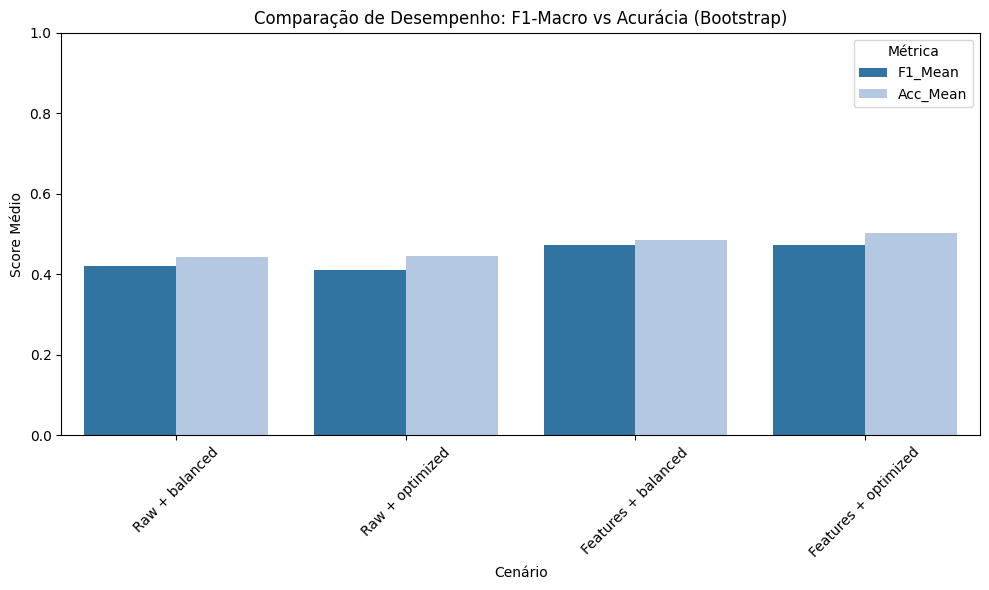

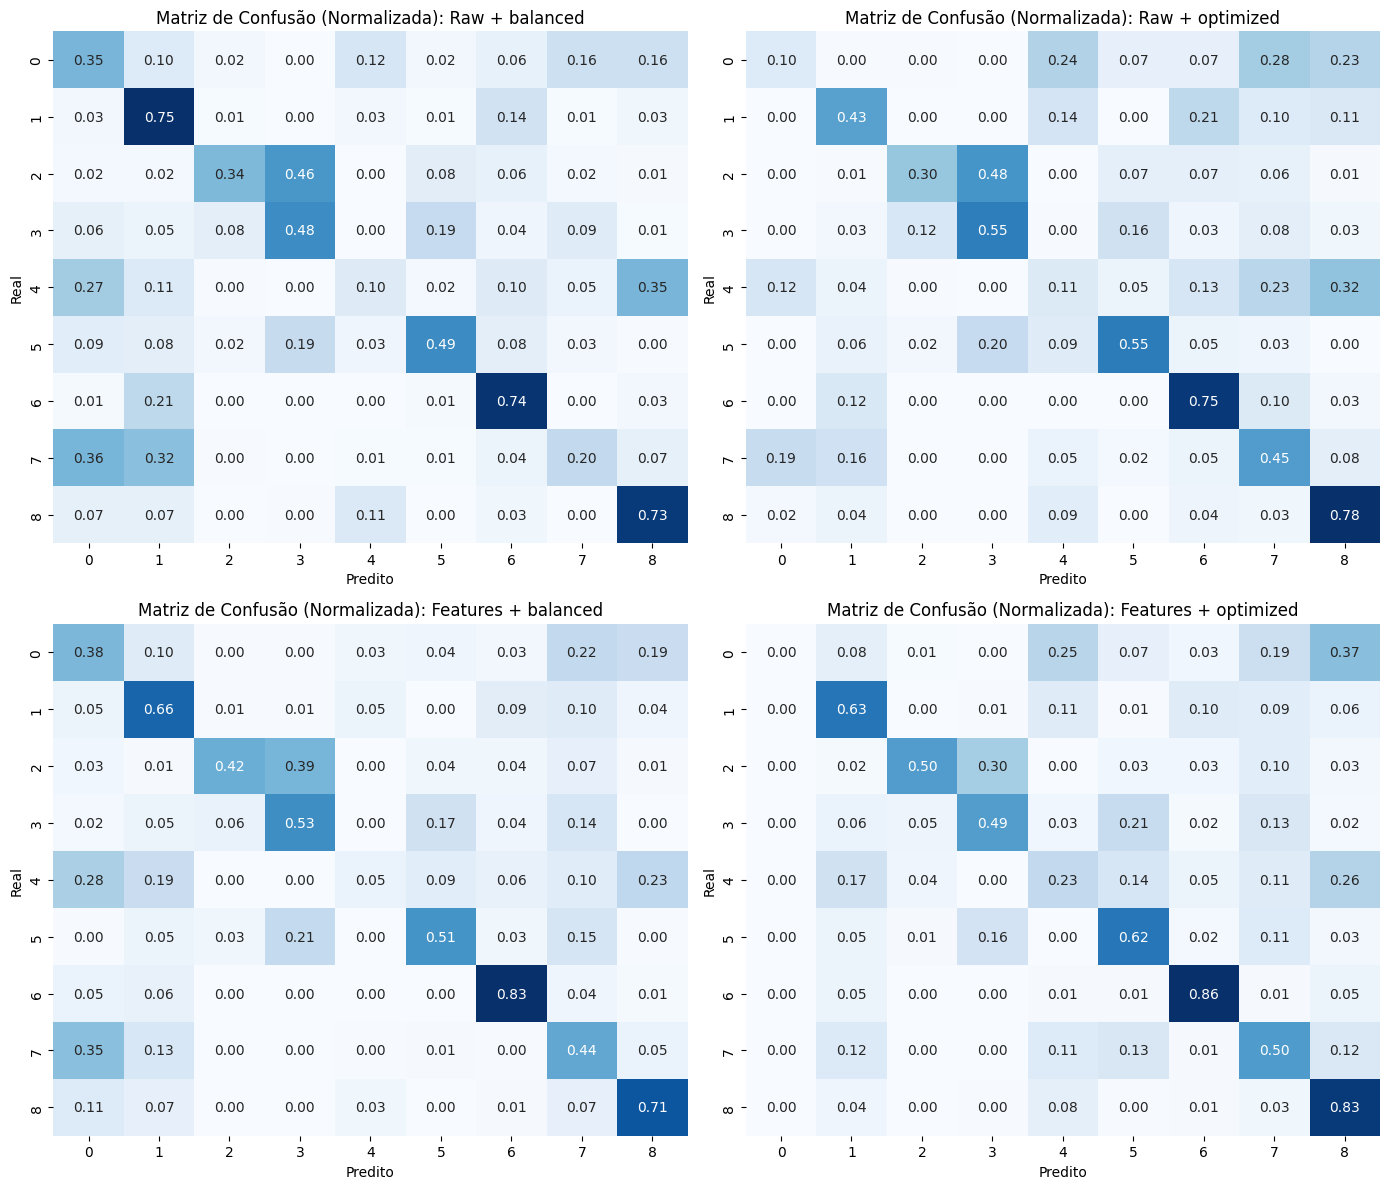

In [40]:
from sklearn.metrics import confusion_matrix
from IPython.display import display

splits = load_data_and_split(NPZ_PATH)

if splits:
    (X_tr, y_tr), (X_val, y_val), (X_te, y_te), NUM_CLASSES = splits
    final_report = []
    cm_data = {}

    scenarios = [("Raw", "balanced"), ("Raw", "optimized"), ("Features", "balanced"), ("Features", "optimized")]

    for data_type, param_type in scenarios:
        mode = 'raw' if data_type == 'Raw' else 'features'

        # 1. Preparação (Scaling)
        # We pass all three sets to keep scaling consistent
        X_tr_sc, X_val_sc, X_te_sc = prep_dl_data(X_tr, X_val, X_te, mode)

        if param_type == 'optimized':
            # Optuna now uses the REAL validation set
            best_params = run_optuna_dl(
                X_tr_sc, y_tr, X_val_sc, y_val, mode, NUM_CLASSES
            )
        else:
            best_params = 'balanced'

        # 2. Rodar Experimentos
        res = run_experiments_dl(
            X_tr_sc, y_tr, X_val_sc, y_val, X_te_sc, y_te, # Added Val sets
            best_params, mode, NUM_CLASSES, f"{data_type} + {param_type}"
        )

        # Remove predições para não poluir o DataFrame e armazena para a matriz
        cm_data[res['Cenário']] = (res.pop('y_test'), res.pop('y_pred'))
        final_report.append(res)
        gc.collect()

    # --- RELATÓRIO ---
    df_results = pd.DataFrame(final_report)
    print("\n\n RELATÓRIO FINAL: DEEP LEARNING (HU-USP)")
    display(df_results)

    # Plot Gráfico em Azul (Comparando F1 e Acurácia)
    df_melted = df_results.melt(id_vars='Cenário', value_vars=['F1_Mean', 'Acc_Mean'], var_name='Métrica', value_name='Valor')

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_melted, x='Cenário', y='Valor', hue='Métrica', palette=['#1f77b4', '#aec7e8'])
    plt.title('Comparação de Desempenho: F1-Macro vs Acurácia (Bootstrap)')
    plt.ylabel('Score Médio')
    plt.ylim(0.0, 1.0)
    plt.xticks(rotation=45)
    plt.legend(title='Métrica')
    plt.tight_layout()
    plt.show()

    # Matrizes de Confusão em um grid
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    for idx, (cenario, (y_t, y_p)) in enumerate(cm_data.items()):
        cm = confusion_matrix(y_t, y_p, normalize='true')
        sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=axes[idx], cbar=False)
        axes[idx].set_title(f'Matriz de Confusão (Normalizada): {cenario}')
        axes[idx].set_xlabel('Predito')
        axes[idx].set_ylabel('Real')

    plt.tight_layout()
    plt.show()

else:
    print(" Erro ao carregar dados.")